<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

In [ ]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00



--- [0. データクレンジング: 重複・矛盾の解消] ---
▼ 処理結果: 1568 行 -> 1472 行 (計 96 行を圧縮・削除)

--- [1. Optuna パラメータ最適化] ---
💡 Optunaが導き出した理想の木の数 (n_estimators): 358 回

--- [2. 学習フェーズ開始 (LGBM x3種, XGBoost, CatBoost)] ---
✅ 学習完了: 最終 OOF AUC: 0.8704

🏆 最終ローカルCVスコア (AUC): 0.8704
📉 最終損失 (Log Loss): 0.3174

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 計 75 個のモデルによるアンサンブル予測を実行しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 225 件 / 1472 件

▼ 損失原因度ランキング トップ5:
                    Feature  Error_Importance
0         loyalty_x_vintage         53.795384
1            recent_loyalty         10.104308
2  days_since_last_purchase          6.975616
3             annual_income          6.883944
4         income_per_capita          4.940824

--- [5. 特徴量重要度の算出] ---


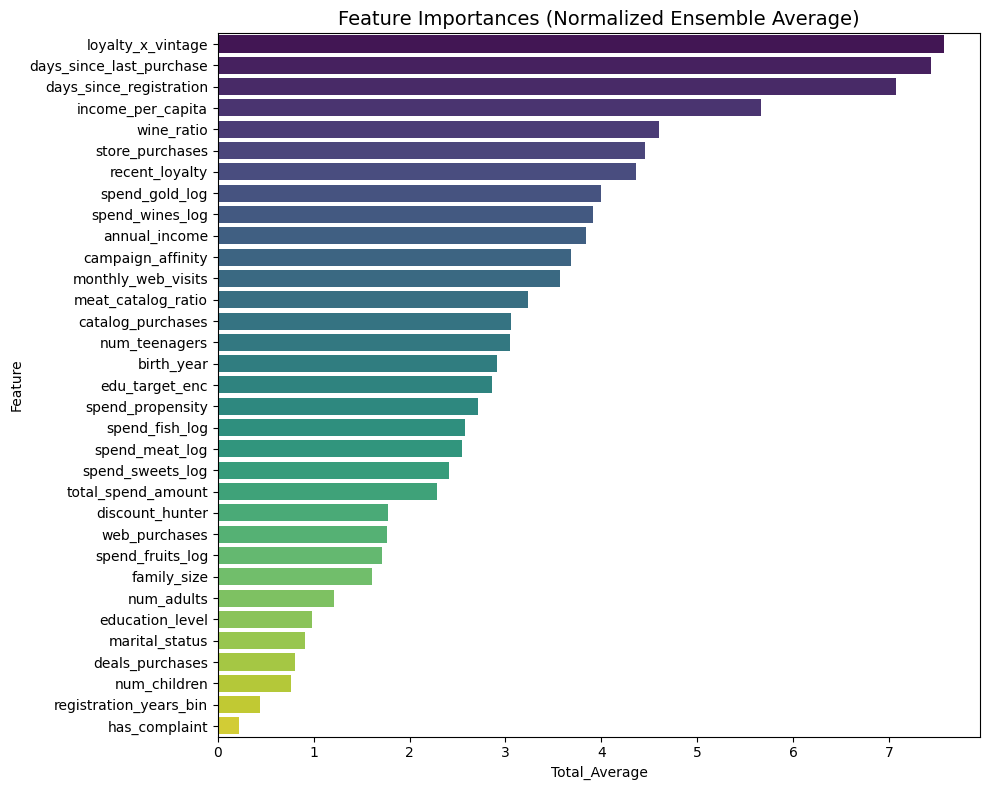


✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！


In [22]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
# ==========================================
# 0-A. データクレンジング: 重複・矛盾の解消
# ==========================================
def resolve_conflicts_by_majority(df):
    print("\n--- [0. データクレンジング: 重複・矛盾の解消] ---")
    df_clean = df.copy()
    original_len = len(df_clean)

    # 1. 完全一致の重複を1件に絞る
    dup_cols = [col for col in df_clean.columns if col != 'customer_id']
    df_clean = df_clean.drop_duplicates(subset=dup_cols, keep='first')

    # 2. 特徴量は同じでターゲットが異なる「矛盾データ」の多数決処理
    if 'target' in df_clean.columns:
        feature_cols = [col for col in df_clean.columns if col not in ['customer_id', 'target']]
        grouped_target = df_clean.groupby(feature_cols, dropna=False)['target'].mean()
        resolved_targets = (grouped_target > 0.5).astype(int).reset_index()
        customer_ids = df_clean.groupby(feature_cols, dropna=False)['customer_id'].first().reset_index()

        df_resolved = pd.merge(customer_ids, resolved_targets, on=feature_cols)
        df_resolved = df_resolved[df_clean.columns]
    else:
        df_resolved = df_clean

    print(f"▼ 処理結果: {original_len} 行 -> {len(df_resolved)} 行 (計 {original_len - len(df_resolved)} 行を圧縮・削除)")
    return df_resolved

# ==========================================
# 0-B. 絶対にリークしない事前処理 + 重複変数の削除修正版
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    # 1. 登録日数の計算とビニング
    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

        df['registration_years_bin'] = pd.cut(
            df['days_since_registration'],
            bins=[-1, 365, 730, 1095, 9999],
            labels=[1, 2, 3, 4]
        ).astype(float)

    # 2. ロイヤルティの計算 (ここはまだ生の spend_wines 等を使う)
    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        raw_loyalty = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)
        df['recent_loyalty'] = np.log1p(raw_loyalty)

        if 'registration_years_bin' in df.columns:
            df['loyalty_x_vintage'] = df['recent_loyalty'] * df['registration_years_bin']

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        raw_meat_ratio = df['spend_meat'] / (df['catalog_purchases'] + 1)
        df['meat_catalog_ratio'] = np.log1p(raw_meat_ratio)

    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)

        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    # 3. 家族構成とお財布事情 (生データを使う)
    if all(c in df.columns for c in ['marital_status', 'num_children', 'num_teenagers']):
        df['num_adults'] = df['marital_status'].apply(lambda x: 2 if x in ['Married', 'Partner'] else 1)
        df['family_size'] = df['num_adults'] + df['num_children'] + df['num_teenagers']
        df['income_per_capita'] = df['annual_income'] / df['family_size']

    spend_raw_cols = [c for c in df.columns if c.startswith('spend_') and not c.endswith('_log')]
    if spend_raw_cols and 'annual_income' in df.columns:
        df['total_spend_amount'] = df[spend_raw_cols].sum(axis=1)
        df['spend_propensity'] = df['total_spend_amount'] / (df['annual_income'] + 1)

        if 'spend_wines' in df.columns:
            df['wine_ratio'] = df['spend_wines'] / (df['total_spend_amount'] + 1)

    # 🌟 4. [最重要修正] 生の支出データをLog変換した後、元データを確実にDropする！
    for col in spend_raw_cols:
        df[col + '_log'] = np.log1p(df[col])
        df = df.drop(col, axis=1) # 👈 これで双子特徴量による重要度分散と精度低下を防ぐ

    return df

# ==========================================
# 1. Optuna (パラメータチューニング)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1. Optuna パラメータ最適化] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        fold_best_iters = []

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            # 🌟 [改善2] Optuna内でもTarget Encodingを実施
            edu_te_map = y_tr.groupby(X_tr['education_level']).mean()
            X_tr['edu_target_enc'] = X_tr['education_level'].map(edu_te_map)
            X_va['edu_target_enc'] = X_va['education_level'].map(edu_te_map).fillna(y_tr.mean())

            cols = ['education_level', 'marital_status']
            for col in cols:
                train_categories = X_tr[col].astype('category').cat.categories
                X_tr[col] = pd.Categorical(X_tr[col], categories=train_categories)
                X_va[col] = pd.Categorical(X_va[col], categories=train_categories)

            model = LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.best_iteration_)

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_n_estimators = study.best_trial.user_attrs['optimal_iterations']
    print(f"💡 Optunaが導き出した理想の木の数 (n_estimators): {best_n_estimators} 回")

    best_params.update({
        'random_state': 42,
        'n_estimators': best_n_estimators,
        'class_weight': 'balanced',
        'verbose': -1
    })
    return best_params

# ==========================================
# 2. 学習フェーズ + 🌟 多様性アンサンブル
# ==========================================
def train_models(X_raw, y, lgb_best_params):
    print(f"\n--- [2. 学習フェーズ開始 (LGBM x3種, XGBoost, CatBoost)] ---")
    artifacts = []

    n_splits, n_repeats = 5, 3
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=777)

    oof_preds_sum = np.zeros(len(X_raw))
    oof_counts = np.zeros(len(X_raw))

    categorical_cols = ['education_level', 'marital_status']
    optimal_iters = lgb_best_params['n_estimators']

    for fold, (train_idx, val_idx) in enumerate(rskf.split(X_raw, y)):
        X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
        X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

        ratio_tr = float(np.sum(y_tr == 0)) / np.sum(y_tr == 1)

        income_median = X_tr['annual_income'].median()
        X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
        X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

        # 🌟 [改善2] education_level のTarget Encoding (KFold内でリークなし)
        edu_te_map = y_tr.groupby(X_tr['education_level']).mean()
        fallback_mean = y_tr.mean()
        X_tr['edu_target_enc'] = X_tr['education_level'].map(edu_te_map)
        X_va['edu_target_enc'] = X_va['education_level'].map(edu_te_map).fillna(fallback_mean)

        # --- 各アルゴリズム向けのカテゴリ処理 ---
        X_tr_cat = X_tr.copy()
        X_va_cat = X_va.copy()
        X_tr_cat[categorical_cols] = X_tr_cat[categorical_cols].astype(str)
        X_va_cat[categorical_cols] = X_va_cat[categorical_cols].astype(str)

        X_tr_lgb = X_tr.copy()
        X_va_lgb = X_va.copy()
        for col in categorical_cols:
            train_categories = X_tr_lgb[col].astype('category').cat.categories
            X_tr_lgb[col] = pd.Categorical(X_tr_lgb[col], categories=train_categories)
            X_va_lgb[col] = pd.Categorical(X_va_lgb[col], categories=train_categories)

        X_tr_xgb = X_tr.copy()
        X_va_xgb = X_va.copy()
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_tr_xgb[categorical_cols] = encoder.fit_transform(X_tr_xgb[categorical_cols])
        X_va_xgb[categorical_cols] = encoder.transform(X_va_xgb[categorical_cols])

        # 🌟 [改善3] モデルの多様性強化 (Optuna版、浅い版、深い版)
        lgb_params = lgb_best_params.copy()
        lgb_params['random_state'] = fold

        models = {
            'LightGBM_Optuna': LGBMClassifier(**lgb_params),
            'LightGBM_Shallow': LGBMClassifier(**{**lgb_params, 'max_depth': 3, 'num_leaves': 7}),
            'LightGBM_Deep': LGBMClassifier(**{**lgb_params, 'max_depth': 8, 'num_leaves': 63}),
            'XGBoost': XGBClassifier(random_state=fold, n_estimators=optimal_iters, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio_tr, eval_metric='logloss'),
            'CatBoost': CatBoostClassifier(random_state=fold, iterations=optimal_iters, learning_rate=0.05, depth=5, auto_class_weights='Balanced', cat_features=categorical_cols, verbose=False)
        }

        fold_val_preds = np.zeros(len(X_va))

        for name, model in models.items():
            if 'LightGBM' in name:
                model.fit(X_tr_lgb, y_tr)
                fold_val_preds += model.predict_proba(X_va_lgb)[:, 1] / len(models)
            elif name == 'XGBoost':
                model.fit(X_tr_xgb, y_tr, verbose=False)
                fold_val_preds += model.predict_proba(X_va_xgb)[:, 1] / len(models)
            elif name == 'CatBoost':
                model.fit(X_tr_cat, y_tr, verbose=False)
                fold_val_preds += model.predict_proba(X_va_cat)[:, 1] / len(models)

        oof_preds_sum[val_idx] += fold_val_preds
        oof_counts[val_idx] += 1

        artifacts.append({
            'fold': fold,
            'preprocessors': {
                'income_median': income_median,
                'encoder': encoder,
                'cat_cols': categorical_cols,
                'lgb_categories': {col: X_tr_lgb[col].cat.categories for col in categorical_cols},
                'edu_te_map': edu_te_map,         # 🌟 推論用マッピングを保存
                'edu_te_fallback': fallback_mean  # 🌟 推論用バックアップを保存
            },
            'models': models,
            'feature_names': list(X_tr.columns)
        })

    final_oof_preds = oof_preds_sum / oof_counts
    print(f"✅ 学習完了: 最終 OOF AUC: {roc_auc_score(y, final_oof_preds):.4f}")

    return artifacts, final_oof_preds

# ==========================================
# 3. 予測フェーズ
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    for artifact in artifacts:
        preps = artifact['preprocessors']
        models = artifact['models']

        X_te = X_test_raw.copy()

        # --- 共通処理 ---
        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])

        # 🌟 テストデータにTarget Encodingを適用
        X_te['edu_target_enc'] = X_te['education_level'].map(preps['edu_te_map']).fillna(preps['edu_te_fallback'])

        # --- 各アルゴリズム向けのカテゴリ処理 ---
        X_te_cat = X_te.copy()
        X_te_cat[preps['cat_cols']] = X_te_cat[preps['cat_cols']].astype(str)

        X_te_lgb = X_te.copy()
        for col in preps['cat_cols']:
            X_te_lgb[col] = pd.Categorical(X_te_lgb[col], categories=preps['lgb_categories'][col])

        X_te_xgb = X_te.copy()
        X_te_xgb[preps['cat_cols']] = preps['encoder'].transform(X_te_xgb[preps['cat_cols']])

        # --- 推論 ---
        for name, model in models.items():
            if 'LightGBM' in name:
                final_test_preds += model.predict_proba(X_te_lgb)[:, 1]
            elif name == 'XGBoost':
                final_test_preds += model.predict_proba(X_te_xgb)[:, 1]
            elif name == 'CatBoost':
                final_test_preds += model.predict_proba(X_te_cat)[:, 1]
            total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. & 5. 可視化関数
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    error_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)
    print("\n▼ 損失原因度ランキング トップ5:")
    print(error_importance.head(5))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()

    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_data_clean = resolve_conflicts_by_majority(train_data)

    train_df = preprocess_safe_row_wise(train_data_clean)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params)

    # ==========================================
    # 追加: 最終的なローカルCVスコアと損失を計算して表示
    # ==========================================
    final_cv_score = roc_auc_score(y, oof_predictions)
    final_log_loss = log_loss(y, oof_predictions)
    print(f"\n🏆 最終ローカルCVスコア (AUC): {final_cv_score:.4f}")
    print(f"📉 最終損失 (Log Loss): {final_log_loss:.4f}")
    # ==========================================

    final_predictions = predict_models(X_test_raw, artifacts)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_trinity.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_trinity.csv' を出力しました！")